In [42]:
%matplotlib inline
import pandas as pd
import numpy as np
import matplotlib
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder, StandardScaler, MinMaxScaler
from sklearn.decomposition import PCA
#import warnings
#warnings.filterwarnings("ignore")

# STEP 1 - load the dataset
# ======================
df = pd.read_csv("institutional_energy(1).csv")

print("dataset loaded!")
print("shape of dataset is:", df.shape)
print()
print(df.head(10))

dataset loaded!
shape of dataset is: (2141, 22)

   Time_of_Day  Students_Present Temperature_C  Appliance_Usage  Day_of_Week  \
0           18             360.0         16.67             18.0            4   
1           19             597.0         27.24             59.0            7   
2            1             357.0         30.61             23.0            6   
3           22             213.0         25.94              NaN            7   
4           14             457.0         29.09             47.0            4   
5            6             578.0          16.0              NaN            6   
6            3             436.0         21.27             36.0            2   
7            3             440.0         25.67             18.0            4   
8            9             170.0         26.54              4.0            7   
9           14              64.0          37.7             21.0            1   

   Energy_Consumption_kWh  Month  Season Building_Type Weather_Conditi

In [43]:
# STEP 2 - Basic info about dataset
# ================================

print()
print("=== basic info ===")
df.info()

print()
print("=== first 5 rows ===")
print(df.head())

print()
print("=== last 5 rows ===")
print(df.tail())

print()
print("=== statistical summary ===")
print(df.describe())

print()
print("=== shape of data ===")
print("number of rows =", df.shape[0])
print("number of columns =", df.shape[1])


=== basic info ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2141 entries, 0 to 2140
Data columns (total 22 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   Time_of_Day             2141 non-null   int64  
 1   Students_Present        1960 non-null   float64
 2   Temperature_C           1962 non-null   object 
 3   Appliance_Usage         2024 non-null   float64
 4   Day_of_Week             2141 non-null   int64  
 5   Energy_Consumption_kWh  2141 non-null   float64
 6   Month                   2141 non-null   int64  
 7   Season                  2141 non-null   object 
 8   Building_Type           1999 non-null   object 
 9   Weather_Condition       2024 non-null   object 
 10  Occupancy_Level         1976 non-null   object 
 11  Shift                   2141 non-null   object 
 12  HVAC_Mode               2011 non-null   object 
 13  Event_Type              2141 non-null   object 
 14  Maintenance_Status  

In [44]:
# STEP 3 - check null values
# ========================
print()
print("=== checking null values ===")
print(df.isnull().sum())

print()
print("total null values in whole dataset =", df.isnull().sum().sum())

print()
print("=== null values in percentage ===")
print(df.isnull().sum() / len(df) * 100)


=== checking null values ===
Time_of_Day                 0
Students_Present          181
Temperature_C             179
Appliance_Usage           117
Day_of_Week                 0
Energy_Consumption_kWh      0
Month                       0
Season                      0
Building_Type             142
Weather_Condition         117
Occupancy_Level           165
Shift                       0
HVAC_Mode                 130
Event_Type                  0
Maintenance_Status        168
Humidity_Percent          171
Wind_Speed_kmh            123
Solar_Radiation_Wm2       148
HVAC_Usage_kW             110
Lighting_Usage_kW         110
Water_Usage_Liters        118
CO2_Level_ppm             180
dtype: int64

total null values in whole dataset = 2159

=== null values in percentage ===
Time_of_Day               0.000000
Students_Present          8.453993
Temperature_C             8.360579
Appliance_Usage           5.464736
Day_of_Week               0.000000
Energy_Consumption_kWh    0.000000
Month    

In [45]:
# STEP 4 - Check duplicate rows
# ============================

print()
print("=== checking duplicates ===")
print("number of duplicate rows =", df.duplicated().sum())

df = df.drop_duplicates()
df = df.reset_index(drop=True)
print("after removing duplicates, shape is:", df.shape)


=== checking duplicates ===
number of duplicate rows = 21
after removing duplicates, shape is: (2120, 22)


In [46]:
# STEP 5 - Separating columns into numerical and categorical
# =================================================

numerical_columns = [
    'Time_of_Day', 'Students_Present', 'Temperature_C', 'Appliance_Usage',
    'Day_of_Week', 'Month', 'Humidity_Percent', 'Wind_Speed_kmh',
    'Solar_Radiation_Wm2', 'HVAC_Usage_kW', 'Lighting_Usage_kW',
    'Water_Usage_Liters', 'CO2_Level_ppm'
]

categorical_columns = [
    'Season', 'Building_Type', 'Weather_Condition', 'Occupancy_Level',
    'Shift', 'HVAC_Mode', 'Event_Type', 'Maintenance_Status'
]

target_column = 'Energy_Consumption_kWh'

# convert numerical columns to numeric 
print()
print("=== converting numerical columns to numeric dtype ===")
for col in numerical_columns:
    df[col] = pd.to_numeric(df[col], errors='coerce')
    print(f"{col}: dtype={df[col].dtype}, nulls after coerce={df[col].isnull().sum()}")

print()
print("numerical columns are:", numerical_columns)
print()
print("categorical columns are:", categorical_columns)
print()
print("target column is:", target_column)


=== converting numerical columns to numeric dtype ===
Time_of_Day: dtype=int64, nulls after coerce=0
Students_Present: dtype=float64, nulls after coerce=176
Temperature_C: dtype=float64, nulls after coerce=176
Appliance_Usage: dtype=float64, nulls after coerce=116
Day_of_Week: dtype=int64, nulls after coerce=0
Month: dtype=int64, nulls after coerce=0
Humidity_Percent: dtype=float64, nulls after coerce=171
Wind_Speed_kmh: dtype=float64, nulls after coerce=130
Solar_Radiation_Wm2: dtype=float64, nulls after coerce=146
HVAC_Usage_kW: dtype=float64, nulls after coerce=118
Lighting_Usage_kW: dtype=float64, nulls after coerce=108
Water_Usage_Liters: dtype=float64, nulls after coerce=116
CO2_Level_ppm: dtype=float64, nulls after coerce=179

numerical columns are: ['Time_of_Day', 'Students_Present', 'Temperature_C', 'Appliance_Usage', 'Day_of_Week', 'Month', 'Humidity_Percent', 'Wind_Speed_kmh', 'Solar_Radiation_Wm2', 'HVAC_Usage_kW', 'Lighting_Usage_kW', 'Water_Usage_Liters', 'CO2_Level_ppm'

In [47]:
# STEP 6 - label encoding for categorical columns
# ==============================================

print()
print("=== label encoding ===")

label_encoders = {}
for col in categorical_columns:
    le = LabelEncoder()
    df[col] = le.fit_transform(df[col].astype(str))
    label_encoders[col] = le
    print(f"{col} encoded. unique values are: {df[col].unique()}")

print()
print("label encoding done!")
print(df[categorical_columns].head())


=== label encoding ===
Season encoded. unique values are: [1 0 2 3]
Building_Type encoded. unique values are: [2 1 4 6 0 9 3 7 5 8]
Weather_Condition encoded. unique values are: [2 0 6 5 4 8 7 1 9 3]
Occupancy_Level encoded. unique values are: [1 0 3 4 2]
Shift encoded. unique values are: [1 3 0 2]
HVAC_Mode encoded. unique values are: [1 6 4 3 2 0 5]
Event_Type encoded. unique values are: [1 3 7 4 6 2 5 0]
Maintenance_Status encoded. unique values are: [0 2 4 1 3]

label encoding done!
   Season  Building_Type  Weather_Condition  Occupancy_Level  Shift  \
0       1              2                  2                1      1   
1       1              1                  0                0      1   
2       0              4                  6                1      3   
3       0              6                  2                3      1   
4       0              0                  5                1      0   

   HVAC_Mode  Event_Type  Maintenance_Status  
0          1           1         

In [48]:
# STEP 7 - feature and target split
# =================================

print()
print("=== splitting features and target ===")

X = df.drop(columns=['Energy_Consumption_kWh'])
y = df['Energy_Consumption_kWh']

print("shape of X (features):", X.shape)
print("shape of y (target):", y.shape)

print()
print("first 5 rows of X:")
print(X.head())

print()
print("first 5 values of y:")
print(y.head())


=== splitting features and target ===
shape of X (features): (2120, 21)
shape of y (target): (2120,)

first 5 rows of X:
   Time_of_Day  Students_Present  Temperature_C  Appliance_Usage  Day_of_Week  \
0           18             360.0          16.67             18.0            4   
1           19             597.0          27.24             59.0            7   
2            1             357.0          30.61             23.0            6   
3           22             213.0          25.94              NaN            7   
4           14             457.0          29.09             47.0            4   

   Month  Season  Building_Type  Weather_Condition  Occupancy_Level  ...  \
0      5       1              2                  2                1  ...   
1      5       1              1                  0                0  ...   
2     10       0              4                  6                1  ...   
3      9       0              6                  2                3  ...   
4     10   

In [49]:
# STEP 8 - normalization using min max scaler
# =========================================

print()
print("=== normalization using MinMaxScaler ===")

print("before normalization:")
print(X[numerical_columns].describe().round(2))

scaler_minmax = MinMaxScaler()
X[numerical_columns] = scaler_minmax.fit_transform(X[numerical_columns])

print()
print("after normalization (values should be between 0 and 1):")
print(X[numerical_columns].describe().round(2))

print()
print("normalization done!")


=== normalization using MinMaxScaler ===
before normalization:
       Time_of_Day  Students_Present  Temperature_C  Appliance_Usage  \
count      2120.00           1944.00        1944.00          2004.00   
mean         11.82            317.15          28.05            29.69   
std           6.93            372.72          11.16            16.53   
min           0.00              0.00         -42.77             0.00   
25%           6.00            138.00          21.27            16.00   
50%          12.00            281.50          27.91            30.00   
75%          18.00            431.00          34.07            44.00   
max          23.00           4857.00         118.67            59.00   

       Day_of_Week    Month  Humidity_Percent  Wind_Speed_kmh  \
count      2120.00  2120.00           1949.00         1990.00   
mean          3.96     6.59             62.05           25.40   
std           2.00     3.44             19.29           14.18   
min           1.00     1.00

In [50]:
# STEP 9 - standardization using standard scaler 
# ===============================================

print()
print("=== standardization using StandardScaler ===")

df2 = pd.read_csv("institutional_energy(1).csv")
df2 = df2.drop_duplicates().reset_index(drop=True)

for col in categorical_columns:
    le2 = LabelEncoder()
    df2[col] = le2.fit_transform(df2[col].astype(str))

# convert numerical columns to numeric in df2
for col in numerical_columns:
    df2[col] = pd.to_numeric(df2[col], errors='coerce')

X2 = df2.drop(columns=['Energy_Consumption_kWh'])
y2 = df2['Energy_Consumption_kWh']

print("before standardization:")
print(X2[numerical_columns].describe().round(2))

scaler_standard = StandardScaler()
X2[numerical_columns] = scaler_standard.fit_transform(X2[numerical_columns])

print()
print("after standardization (mean should be close to 0):")
print(X2[numerical_columns].describe().round(2))

print()
print("standardization done!")


=== standardization using StandardScaler ===
before standardization:
       Time_of_Day  Students_Present  Temperature_C  Appliance_Usage  \
count      2120.00           1944.00        1944.00          2004.00   
mean         11.82            317.15          28.05            29.69   
std           6.93            372.72          11.16            16.53   
min           0.00              0.00         -42.77             0.00   
25%           6.00            138.00          21.27            16.00   
50%          12.00            281.50          27.91            30.00   
75%          18.00            431.00          34.07            44.00   
max          23.00           4857.00         118.67            59.00   

       Day_of_Week    Month  Humidity_Percent  Wind_Speed_kmh  \
count      2120.00  2120.00           1949.00         1990.00   
mean          3.96     6.59             62.05           25.40   
std           2.00     3.44             19.29           14.18   
min           1.00   

In [51]:
# STEP 10 - Feature transformation (log transform)
# ==============================

print()
print("=== feature transformation (log transform) ===")

X3 = df2.drop(columns=['Energy_Consumption_kWh']).copy()

columns_for_log = ['Students_Present', 'Water_Usage_Liters', 'CO2_Level_ppm', 'Solar_Radiation_Wm2']

for col in columns_for_log:
    X3[col + '_log'] = np.log1p(X3[col])
    print(f"log transform applied on {col}")
    print(f"  before: min={X3[col].min():.2f}, max={X3[col].max():.2f}")
    print(f"  after:  min={X3[col+'_log'].min():.2f}, max={X3[col+'_log'].max():.2f}")

print()
print("log transformation done!")
print("new shape after adding log columns:", X3.shape)


=== feature transformation (log transform) ===
log transform applied on Students_Present
  before: min=0.00, max=4857.00
  after:  min=0.00, max=8.49
log transform applied on Water_Usage_Liters
  before: min=100.90, max=2991.00
  after:  min=4.62, max=8.00
log transform applied on CO2_Level_ppm
  before: min=316.10, max=1179.70
  after:  min=5.76, max=7.07
log transform applied on Solar_Radiation_Wm2
  before: min=0.00, max=998.30
  after:  min=0.00, max=6.91

log transformation done!
new shape after adding log columns: (2120, 25)


In [52]:
# STEP 11 - checking correlation with target
# ====================================
print()
print("=== correlation of features with target ===")

combined = X2.copy()
combined['Energy_Consumption_kWh'] = y2.values

correlation = combined.corr()['Energy_Consumption_kWh'].sort_values(ascending=False)
print(correlation)

print()
print("top 5 features that affect energy consumption:")
print(correlation.head(6))


=== correlation of features with target ===
Energy_Consumption_kWh    1.000000
CO2_Level_ppm             0.432589
Students_Present          0.220418
Appliance_Usage           0.200414
Shift                     0.045617
Temperature_C             0.041822
Building_Type             0.023258
Weather_Condition         0.022030
Season                    0.021410
Month                     0.019604
Event_Type                0.013556
Day_of_Week               0.006416
Wind_Speed_kmh            0.005816
HVAC_Mode                 0.001613
Humidity_Percent         -0.000134
Maintenance_Status       -0.003119
Lighting_Usage_kW        -0.004949
HVAC_Usage_kW            -0.026212
Water_Usage_Liters       -0.028315
Solar_Radiation_Wm2      -0.039642
Time_of_Day              -0.047358
Occupancy_Level          -0.252539
Name: Energy_Consumption_kWh, dtype: float64

top 5 features that affect energy consumption:
Energy_Consumption_kWh    1.000000
CO2_Level_ppm             0.432589
Students_Present      


=== plotting correlation heatmap ===


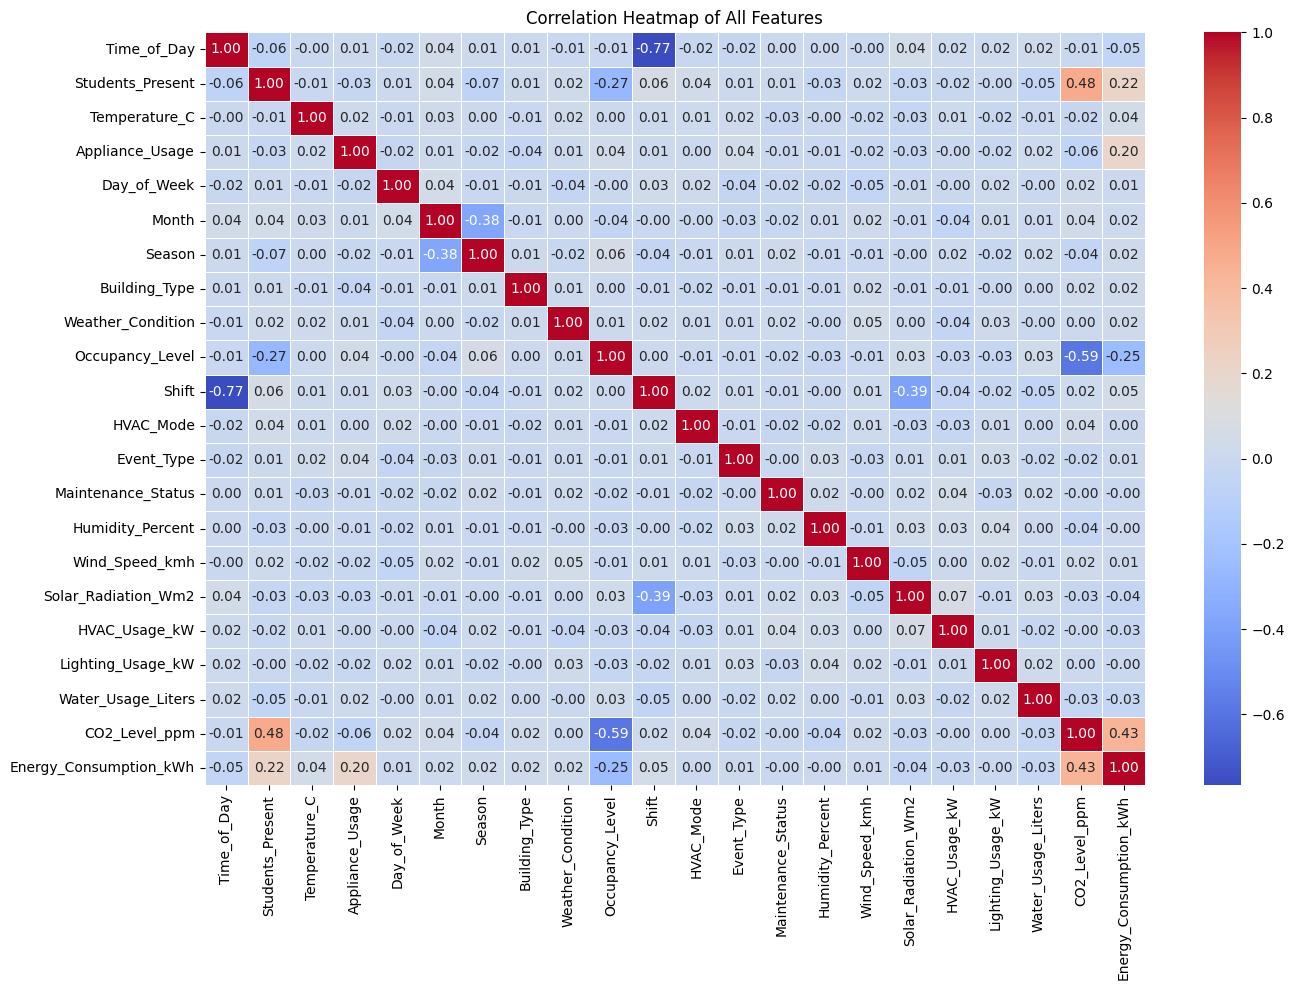

In [54]:
# STEP 12 - plotting correlation heatmap
# =====================================
 
print()
print("=== plotting correlation heatmap ===")
 
plt.figure(figsize=(14, 10))
sns.heatmap(combined.corr(), annot=True, fmt='.2f', cmap='coolwarm', linewidths=0.5)
plt.title("Correlation Heatmap of All Features")
plt.tight_layout()


=== PCA for dimensionality reduction ===
original shape: (1051, 21)
after PCA shape: (1051, 10)

explained variance ratio of each component:
  component 1: 19.10%
  component 2: 18.36%
  component 3: 8.44%
  component 4: 6.68%
  component 5: 5.78%
  component 6: 5.33%
  component 7: 4.47%
  component 8: 4.08%
  component 9: 2.99%
  component 10: 2.77%

total variance explained by 10 components: 77.99 %


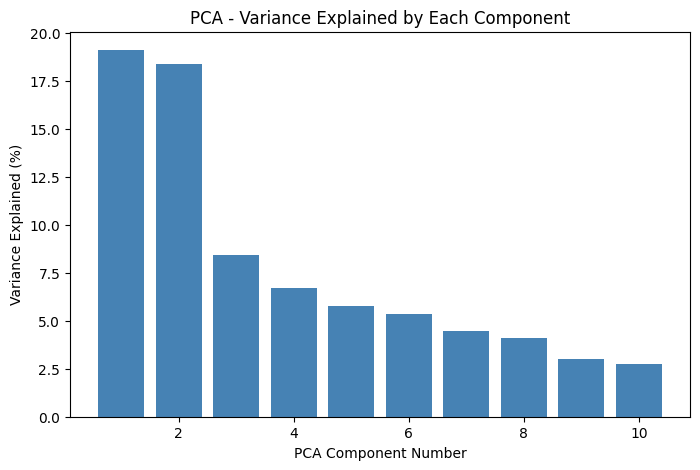

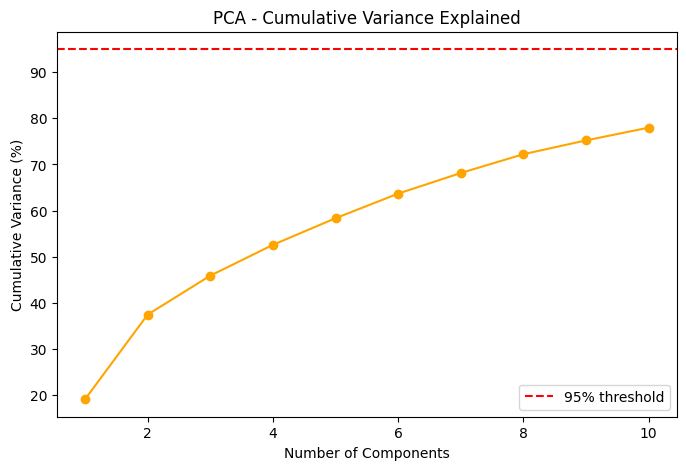

In [55]:
# STEP 13 - PCA
# ===================

print()
print("=== PCA for dimensionality reduction ===")

# Drop rows with NaN before PCA
X2_clean = X2.dropna()
y2_clean = y2[X2_clean.index]
X2_clean = X2_clean.reset_index(drop=True)
y2_clean = y2_clean.reset_index(drop=True)

pca = PCA(n_components=10)
X_pca = pca.fit_transform(X2_clean)

print("original shape:", X2_clean.shape)
print("after PCA shape:", X_pca.shape)

print()
print("explained variance ratio of each component:")
for i, var in enumerate(pca.explained_variance_ratio_):
    print(f"  component {i+1}: {var*100:.2f}%")

print()
print("total variance explained by 10 components:", round(sum(pca.explained_variance_ratio_)*100, 2), "%")

plt.figure(figsize=(8, 5))
plt.bar(range(1, 11), pca.explained_variance_ratio_ * 100, color='steelblue')
plt.xlabel("PCA Component Number")
plt.ylabel("Variance Explained (%)")
plt.title("PCA - Variance Explained by Each Component")


cumulative = np.cumsum(pca.explained_variance_ratio_) * 100
plt.figure(figsize=(8, 5))
plt.plot(range(1, 11), cumulative, marker='o', color='orange')
plt.xlabel("Number of Components")
plt.ylabel("Cumulative Variance (%)")
plt.title("PCA - Cumulative Variance Explained")
plt.axhline(y=95, color='red', linestyle='--', label='95% threshold')
plt.legend()


=== Forward Feature Selection ===
starting forward selection...

step 1: added 'CO2_Level_ppm' --> R2 score = 0.2173
step 2: added 'Appliance_Usage' --> R2 score = 0.3499
step 3: added 'Temperature_C' --> R2 score = 0.3557
step 4: added 'Occupancy_Level' --> R2 score = 0.3611
step 5: added 'Wind_Speed_kmh' --> R2 score = 0.3618
step 6: added 'Time_of_Day' --> R2 score = 0.3623
step 7: added 'Event_Type' --> R2 score = 0.3623
step 8: added 'Weather_Condition' --> R2 score = 0.3620

features selected by forward selection: ['CO2_Level_ppm', 'Appliance_Usage', 'Temperature_C', 'Occupancy_Level', 'Wind_Speed_kmh', 'Time_of_Day', 'Event_Type', 'Weather_Condition']


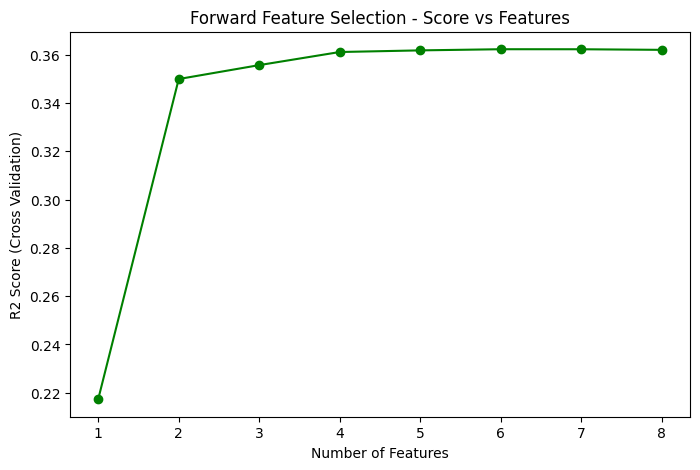

In [56]:
# STEP 14 - Forward Feature Selection
# ================================

print()
print("=== Forward Feature Selection ===")

from sklearn.linear_model import LinearRegression
from sklearn.model_selection import cross_val_score

feature_names = list(X2_clean.columns)

selected_features = []
remaining_features = feature_names.copy()
best_scores = []

print("starting forward selection...")
print()

for step in range(8):
    best_score = -999999
    best_feature = None

    for feature in remaining_features:
        trial_features = selected_features + [feature]
        X_trial = X2_clean[trial_features]

        model = LinearRegression()
        scores = cross_val_score(model, X_trial, y2_clean, cv=5, scoring='r2')
        avg_score = scores.mean()

        if avg_score > best_score:
            best_score = avg_score
            best_feature = feature

    selected_features.append(best_feature)
    remaining_features.remove(best_feature)
    best_scores.append(best_score)

    print(f"step {step+1}: added '{best_feature}' --> R2 score = {best_score:.4f}")

print()
print("features selected by forward selection:", selected_features)

plt.figure(figsize=(8, 5))
plt.plot(range(1, 9), best_scores, marker='o', color='green')
plt.xlabel("Number of Features")
plt.ylabel("R2 Score (Cross Validation)")
plt.title("Forward Feature Selection - Score vs Features")
plt.show()


=== Backward Feature Elimination ===
starting with all 21 features, R2 = 0.3283

step 1: removed 'Students_Present' --> R2 score after removal = 0.3353
step 2: removed 'Day_of_Week' --> R2 score after removal = 0.3415
step 3: removed 'HVAC_Usage_kW' --> R2 score after removal = 0.3449
step 4: removed 'Season' --> R2 score after removal = 0.3483
step 5: removed 'HVAC_Mode' --> R2 score after removal = 0.3519
step 6: removed 'Lighting_Usage_kW' --> R2 score after removal = 0.3543
step 7: removed 'Month' --> R2 score after removal = 0.3563
step 8: removed 'Maintenance_Status' --> R2 score after removal = 0.3585

features removed in order: ['Students_Present', 'Day_of_Week', 'HVAC_Usage_kW', 'Season', 'HVAC_Mode', 'Lighting_Usage_kW', 'Month', 'Maintenance_Status']
features remaining after elimination: ['Time_of_Day', 'Temperature_C', 'Appliance_Usage', 'Building_Type', 'Weather_Condition', 'Occupancy_Level', 'Shift', 'Event_Type', 'Humidity_Percent', 'Wind_Speed_kmh', 'Solar_Radiation_Wm

Text(0.5, 1.0, 'Backward Feature Elimination - Score vs Removed Features')

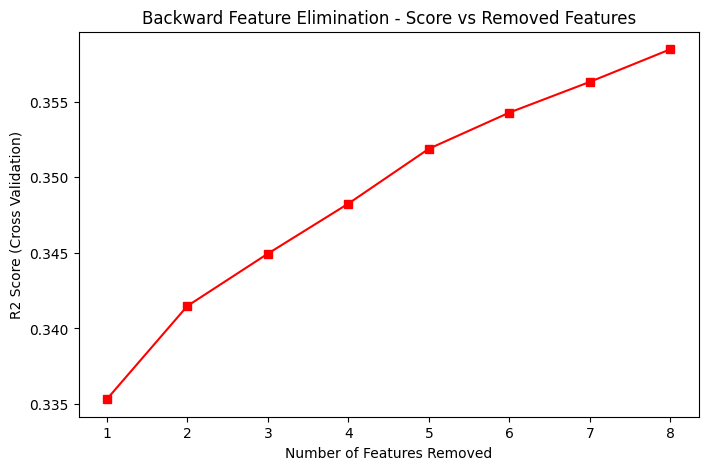

In [57]:
# STEP 15 - Backward Feature Elimination
# =======================
print()
print("=== Backward Feature Elimination ===")

remaining_backward = feature_names.copy()
backward_scores = []
removed_features_log = []

model_all = LinearRegression()
scores_all = cross_val_score(model_all, X2_clean[remaining_backward], y2_clean, cv=5, scoring='r2')
print(f"starting with all {len(remaining_backward)} features, R2 = {scores_all.mean():.4f}")
print()

for step in range(8):
    worst_feature = None
    best_score_after_removal = -999999

    for feature in remaining_backward:
        trial_features = [f for f in remaining_backward if f != feature]
        X_trial = X2_clean[trial_features]

        model = LinearRegression()
        scores = cross_val_score(model, X_trial, y2_clean, cv=5, scoring='r2')
        avg_score = scores.mean()

        if avg_score > best_score_after_removal:
            best_score_after_removal = avg_score
            worst_feature = feature

    remaining_backward.remove(worst_feature)
    removed_features_log.append(worst_feature)
    backward_scores.append(best_score_after_removal)

    print(f"step {step+1}: removed '{worst_feature}' --> R2 score after removal = {best_score_after_removal:.4f}")

print()
print("features removed in order:", removed_features_log)
print("features remaining after elimination:", remaining_backward)

plt.figure(figsize=(8, 5))
plt.plot(range(1, 9), backward_scores, marker='s', color='red')
plt.xlabel("Number of Features Removed")
plt.ylabel("R2 Score (Cross Validation)")
plt.title("Backward Feature Elimination - Score vs Removed Features")

In [59]:
# STEP 16 - Final Preprocessed Data
# =================================

print()
print("=== preparing final preprocessed data ===")

X_final = X2_clean[selected_features].copy()
y_final = y2_clean.copy()

X_pca_df = pd.DataFrame(X_pca, columns=[f'PCA_Component_{i+1}' for i in range(10)])

print("final X shape (forward selected features):", X_final.shape)
print("final y shape:", y_final.shape)
print()
print("final selected features:", selected_features)
print()
print("first 5 rows of final X:")
print(X_final.head())

X_final_to_save = X_final.copy()
X_final_to_save['Energy_Consumption_kWh'] = y_final.values
X_final_to_save.to_csv("preprocessed_data.csv", index=False)
print()
print("preprocessed data saved to preprocessed_data.csv")

X_pca_to_save = X_pca_df.copy()
X_pca_to_save['Energy_Consumption_kWh'] = y_final.values
X_pca_to_save.to_csv("preprocessed_data_pca.csv", index=False)
print("pca version saved to preprocessed_data_pca.csv")

print()
print("=== ALL PREPROCESSING DONE SUCCESSFULLY ===")
print("files saved:")
print("  1. preprocessed_data.csv       - forward selected features")
print("  2. preprocessed_data_pca.csv   - pca components")


=== preparing final preprocessed data ===
final X shape (forward selected features): (1051, 8)
final y shape: (1051,)

final selected features: ['CO2_Level_ppm', 'Appliance_Usage', 'Temperature_C', 'Occupancy_Level', 'Wind_Speed_kmh', 'Time_of_Day', 'Event_Type', 'Weather_Condition']

first 5 rows of final X:
   CO2_Level_ppm  Appliance_Usage  Temperature_C  Occupancy_Level  \
0       0.345846        -0.404780       0.229597                1   
1       0.840539         1.047644       0.093314                1   
2       0.782462        -0.707368      -0.213323                1   
3      -0.006766        -1.554616      -0.135319                4   
4      -0.763844         1.047644       0.798938                2   

   Wind_Speed_kmh  Time_of_Day  Event_Type  Weather_Condition  
0        1.608631    -1.561673           1                  6  
1        1.707401     0.314840           4                  5  
2        1.566301    -1.272979           2                  2  
3       -0.331493